In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

In [3]:
# scale data
def scale(X, X_min, X_max):
    return (X - X_min)/(X_max-X_min)

epochs = 1000
batch_sizes = [4,8,16,32,64]
num_neurons = 10
no_folds = 5

seed = 10

np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.optimizer.set_jit(True)

In [4]:
#read train data
train_input = np.genfromtxt('ctg_data_cleaned.csv', delimiter= ',')
x, y = train_input[1:, :21], train_input[1:,-1].astype(int)
x = scale(x, np.min(x, axis=0), np.max(x, axis=0))
y = y-1

no_data = len(x)
nf = no_data//no_folds

In [7]:
accuracies = {}
timings = []
def get_mean_accuracy(fold_accuracies):
    res =[]
    for i in range(epochs):
        sum=0
        for j in range(no_folds):
            sum+=fold_accuracies[j][i]
        res.append(sum/no_folds)
        
    return res

In [8]:
timings_model_4 = []
accuracies_model_4 = []
for fold in range(no_folds):
    
    histories = {}
    start, end = fold*nf, (fold+1)*nf
    x_test, y_test = x[start:end], y[start:end]
    x_train  = np.append(x[:start], x[end:], axis=0)
    y_train = np.append(y[:start], y[end:], axis=0) 
    
    # Create the model
    model_4 = keras.Sequential([
        keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
        keras.layers.Dense(3, activation='softmax')
    ])

    #Compile the model
    model_4.compile(optimizer='SGD',
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])



    # Train the model
    tic = time.clock()
    history =model_4.fit(x_train, y_train,
                                            validation_data = (x_test, y_test),
                                            epochs=epochs,
                                            verbose = 0,
                                            batch_size=4)
    
    toc = time.clock()
    print('Training complete for fold {}'.format(fold+1))
    
    time_per_epoch = (toc-tic)/1000
    timings_model_4.append(time_per_epoch)
    accuracies_model_4.append(history.history['accuracy'])
   
model_4_accuracy =  get_mean_accuracy(accuracies_model_4)
accuracies['model_4'] = model_4_accuracy
timings.append(np.mean(timings_model_4))
    


    

[0.37075114544]


In [ ]:
model_8 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

#Compile the model
model_8.compile(optimizer='SGD',
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# Train the model
tic = time.clock()
histories['model_4'] =model_8.fit(x_train, y_train,
                                        validation_data = (x_test, y_test),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=8)
toc = time.clock()  
   
print('Training complete')

accuracies['8'] = cross_val_score(estimator=classifier,X=x_train,y=y_train)
time_per_epoch_8 = (toc-tic)/1000

In [ ]:
model_16 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

#Compile the model
model_16.compile(optimizer='SGD',
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# Train the model
tic = time.clock()
histories['model_16'] =model_16.fit(x_train, y_train,
                                        validation_data = (x_test, y_test),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=16)
toc = time.clock()  
   
print('Training complete')

accuracies['16'] = cross_val_score(estimator=classifier,X=x_train,y=y_train)
time_per_epoch_16 = (toc-tic)/1000

In [ ]:
model_32 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

#Compile the model
model_32.compile(optimizer='SGD',
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# Train the model
tic = time.clock()
histories['model_32'] =model_32.fit(x_train, y_train,
                                        validation_data = (x_test, y_test),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=8)
toc = time.clock()  
   
print('Training complete')

accuracies['32'] = cross_val_score(estimator=classifier,X=x_train,y=y_train)
time_per_epoch_32 = (toc-tic)/1000

In [ ]:
model_64 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

#Compile the model
model_64.compile(optimizer='SGD',
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

# Train the model
tic = time.clock()
histories['model_64'] =model_64.fit(x_train, y_train,
                                        validation_data = (x_test, y_test),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=64)
toc = time.clock()  
   
print('Training complete')

accuracies['64'] = cross_val_score(estimator=classifier,X=x_train,y=y_train)
time_per_epoch_64 = (toc-tic)/1000

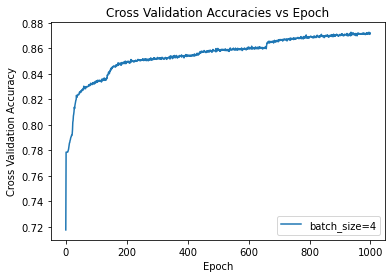

In [11]:
plt.plot(accuracies['model_4'])
'''
plt.plot(accuracies['model_8'])
plt.plot(accuracies['model_16'])
plt.plot(accuracies['model_32'])
plt.plot(accuracies['model_64'])
'''
plt.title('Cross Validation Accuracies vs Epoch')
plt.ylabel('Cross Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(['batch_size=4', 'batch_size=8', 'batch_size=16', 'batch_size=32', 'batch_size=64'], loc='lower right')
plt.show()
    

In [ ]:
plt.plot([time_per_epoch_4, time_per_epoch_8, time_per_epoch_16, time_per_epoch_32, time_per_epoch_64], [4,8,16,32,64])
plt.title('Time per Epoch vs Batch Size')
plt.ylabel('Seconds')
plt.xlabel('Batch Size')
plt.show()